<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Transformer Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
The attention folder built the main part already. A transformer is that block plus three things around it, positional encoding because attention has no idea about order, a feed forward layer, and residual connections with layer norm so a deep stack can actually train.
</div>

## the shape of it

```
tokens
  |
embedding  +  positional encoding
  |
[ attention  ->  add & norm  ->  feed forward  ->  add & norm ]   x N layers
  |
linear to vocabulary
```

no recurrence anywhere. every position is processed at the same time, wich is the whole reason it is fast on a gpu.

## attention has no sense of order

this is easy to miss. attention is a weighted average, and a sum does not care about the order of what it is summing. so if the words are shuffled, the outputs are the same, just shuffled with them.

proving it below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def attention(X):
    d = X.shape[1]
    w = softmax(X @ X.T / np.sqrt(d), axis=-1)
    return w @ X

rng = np.random.default_rng(0)
X = rng.normal(0, 1, (4, 8))          # 4 words, 8 numbers each

out1 = attention(X)
shuffled = X[[2, 0, 3, 1]]            # same words, diffrent order
out2 = attention(shuffled)

print("output for word at original position 2 :", np.round(out1[2][:4], 4))
print("same word after shuffling              :", np.round(out2[0][:4], 4))
print("identical :", np.allclose(out1[2], out2[0]))

output for word at original position 2 : [-0.3344 -0.4346  0.1307  0.5152]
same word after shuffling              : [-0.3344 -0.4346  0.1307  0.5152]
identical : True


the same word gets exactly the same output no matter where it sits. so `dog bites man` and `man bites dog` would be identical to a transformer, wich is obviously useless.

## positional encoding

the fix is to add a vector to each token that says where it is. the original paper uses sines and cosines of diffrent frequencies.

(50, 64)


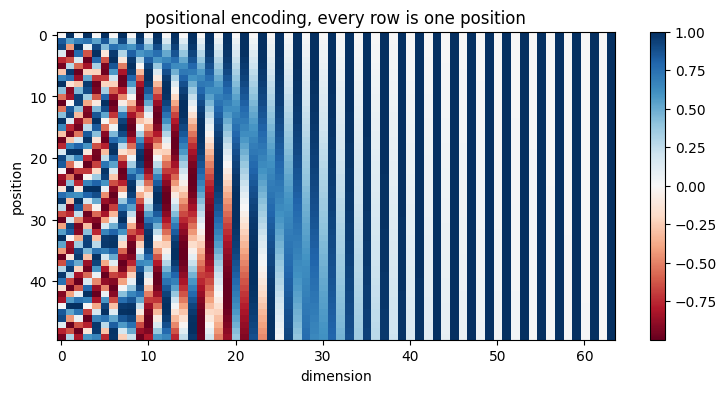

In [10]:
def positional_encoding(T, d):
    pos = np.arange(T)[:, None]
    i = np.arange(d)[None, :]
    angle = pos / np.power(10000, (2 * (i // 2)) / d)
    pe = np.zeros((T, d))
    pe[:, 0::2] = np.sin(angle[:, 0::2])
    pe[:, 1::2] = np.cos(angle[:, 1::2])
    return pe

PE = positional_encoding(50, 64)
print(PE.shape)

plt.figure(figsize=(9,4))
plt.imshow(PE, cmap='RdBu', aspect='auto')
plt.colorbar()
plt.xlabel('dimension'); plt.ylabel('position')
plt.title('positional encoding, every row is one position')
plt.show()

the left columns change fast and the right columns change slowly, so each position gets a unique pattern, a bit like binary counting written with waves.

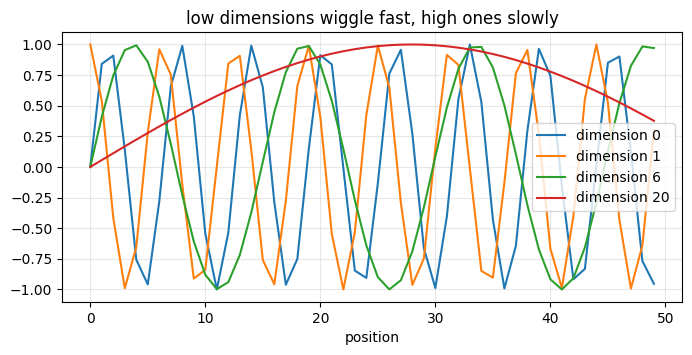

In [3]:
plt.figure(figsize=(8,3.5))
for dim in [0, 1, 6, 20]:
    plt.plot(PE[:, dim], label='dimension ' + str(dim))
plt.xlabel('position'); plt.legend(); plt.grid(alpha=.3)
plt.title('low dimensions wiggle fast, high ones slowly')
plt.show()

the useful property is that nearby positions get similar vectors, so the model can tell not just where a token is but how far apart two tokens are.

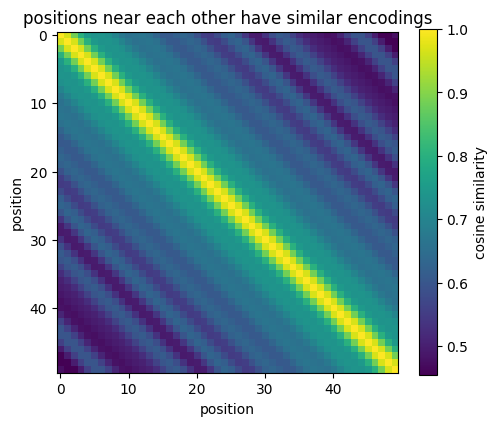

similarity of position 10 with 11 : 0.966
similarity of position 10 with 40 : 0.533


In [4]:
sim = PE @ PE.T
sim = sim / np.linalg.norm(PE, axis=1, keepdims=True) / np.linalg.norm(PE, axis=1)[None, :]

plt.figure(figsize=(5.5,4.5))
plt.imshow(sim, cmap='viridis')
plt.colorbar(label='cosine similarity')
plt.xlabel('position'); plt.ylabel('position')
plt.title('positions near each other have similar encodings')
plt.show()

print("similarity of position 10 with 11 :", round(sim[10,11], 3))
print("similarity of position 10 with 40 :", round(sim[10,40], 3))

## does adding it actually fix the order problem

In [6]:
X = rng.normal(0, 1, (4, 8))
pe = positional_encoding(4, 8)

out1 = attention(X + pe)                       # word at position 2
out2 = attention(X[[2,0,3,1]] + pe)            # same word now at position 0

print("same word, position 2 :", np.round(out1[2][:4], 4))
print("same word, position 0 :", np.round(out2[0][:4], 4))
print("identical :", np.allclose(out1[2], out2[0]))

same word, position 2 : [ 2.5539  0.9396  0.5641 -0.137 ]
same word, position 0 : [ 1.6955  2.2061  0.362  -0.0863]
identical : False


now the outputs are diffrent, so the position is being used.

## the feed forward part

after attention each position goes through its own small MLP, usually `d -> 4d -> d`. attention mixes information **between** positions, the feed forward layer then processes each position on its own. one moves data sideways, the other does the thinking.

most of the parameters of a transformer are actually in these feed forward layers, not in attention.

In [7]:
d = 64
attn_params = 4 * d * d          # Q, K, V and the output projection
ff_params = d * 4*d + 4*d * d    # up and back down

print("attention parameters   :", attn_params)
print("feed forward parameters:", ff_params)
print("feed forward is", round(ff_params / attn_params, 1), "times bigger")

attention parameters   : 16384
feed forward parameters: 32768
feed forward is 2.0 times bigger


## residual and layer norm

each sub layer is wrapped like `x = x + sublayer(norm(x))`.

- the **residual** `x +` gives the gradient a straight path from the loss to the early layers. without it a 12 layer stack does not train, same vanishing problem as the RNN folder but through depth instead of time
- **layer norm** keeps the numbers at each position in a stable range so one exploding feature cannot ruin the rest

In [8]:
def layer_norm(x, eps=1e-5):
    mu = x.mean(axis=-1, keepdims=True)
    sd = x.std(axis=-1, keepdims=True)
    return (x - mu) / (sd + eps)

messy = np.array([[1.0, 2.0, 300.0, 4.0]])
print("before :", messy)
print("after  :", np.round(layer_norm(messy), 3))
print("mean after :", round(float(layer_norm(messy).mean()), 6),
      " std after :", round(float(layer_norm(messy).std()), 3))

before : [[  1.   2. 300.   4.]]
after  : [[-0.588 -0.58   1.732 -0.564]]
mean after : 0.0  std after : 1.0


### recap

- attention alone cannot tell `dog bites man` from `man bites dog`, i proved that above
- positional encoding adds a wave pattern per position, nearby positions come out similar
- attention moves information between positions, the feed forward layer thinks about each position alone, and it holds most of the parameters
- residual connections are what make a deep stack trainable, layer norm keeps the scale sane
- put together, thats the whole architecture. building it in torch in notebook 02